# Предсказание критической температуры сверхпроводников

**Описание на Kaggle:** https://www.kaggle.com/competitions/critical-temperature

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 100
np.random.seed(RANDOM_STATE)

## Загрузка и исследование данных

In [98]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
formula_train = pd.read_csv('formula_train.csv')
formula_test = pd.read_csv('formula_test.csv')

print(f"Размер тренировочного набора: {train.shape}")
print(f"Размер тестового набора: {test.shape}")
print(f"Размер formula_train: {formula_train.shape}")
print(f"Размер formula_test: {formula_test.shape}")

Размер тренировочного набора: (17010, 82)
Размер тестового набора: (4253, 81)
Размер formula_train: (17010, 88)
Размер formula_test: (4253, 87)


In [99]:
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,53.622535,775.425,1010.268571,718.152900,938.016780,1.305967,0.791488,810.6,735.985714,323.811808,355.562967,160.25,105.514286,136.126003,84.528423,1.259244,1.207040,205,42.914286,75.237540,69.235569,4654.35725,2961.502286,724.953211,53.543811,1.033129,0.814598,8958.571,1579.583429,3306.162897,3572.596624,81.8375,111.727143,60.123179,99.414682,1.159687,0.787382,127.05,80.987143,51.433712,42.558396,6.9055,3.846857,3.479475,1.040986,1.088575,0.994998,12.878,1.744571,4.599064,4.666920,107.756645,61.015189,7.062488,0.621979,0.308148,0.262848,399.97342,57.127669,168.854244,138.517163,2.25,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,53.979870,766.440,1010.612857,720.605511,938.745413,1.544145,0.807078,810.6,743.164286,290.183029,354.963511,161.20,104.971429,141.465215,84.370167,1.508328,1.204115,205,50.571429,67.321319,68.008817,5821.48580,3021.016571,1237.095080,54.095718,1.314442,0.914802,10488.571,1667.383429,3767.403176,3632.649185,90.8900,112.316429,69.833315,101.166398,1.427997,0.838666,127.05,81.207857,49.438167,41.667621,7.7844,3.796857,4.403790,1.035251,1.374977,1.073094,12.878,1.595714,4.473363,4.603000,172.205316,61.372331,16.064228,0.619735,0.847404,0.567706,429.97342,51.413383,198.554600,139.630922,2.00,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,53.656268,775.425,1010.820000,718.152900,939.009036,1.305967,0.773620,810.6,743.164286,323.811808,354.804183,160.25,104.685714,136.126003,84.214573,1.259244,1.132547,205,49.314286,75.237540,67.797712,4654.35725,2999.159429,724.953211,53.974022,1.033129,0.760305,8958.571,1667.383429,3306.162897,3592.019281,81.8375,112.213571,60.123179,101.082152,1.159687,0.786007,127.05,81.207857,51.433712,41.639878,6.9055,3.822571,3.479475,1.037439,1.088575,0.927479,12.878,1.757143,4.599064,4.649635,107.756645,60.943760,7.062488,0.619095,0.308148,0.250477,399.97342,57.127669,168.854244,138.540613,2.25,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,53.639405,775.425,1

In [100]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               17010 non-null  int64  
 1   mean_atomic_mass                 17010 non-null  float64
 2   wtd_mean_atomic_mass             17010 non-null  float64
 3   gmean_atomic_mass                17010 non-null  float64
 4   wtd_gmean_atomic_mass            17010 non-null  float64
 5   entropy_atomic_mass              17010 non-null  float64
 6   wtd_entropy_atomic_mass          17010 non-null  float64
 7   range_atomic_mass                17010 non-null  float64
 8   wtd_range_atomic_mass            17010 non-null  float64
 9   std_atomic_mass                  17010 non-null  float64
 10  wtd_std_atomic_mass              17010 non-null  float64
 11  mean_fie                         17010 non-null  float64
 12  wtd_mean_fie      

In [101]:
train.describe()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000,17010.000000
mean,4.113874,87.534919,73.000381,71.308789,58.599393,1.165500,1.063972,115.443468,33.228642,44.320187,41.347802,769.945102,870.933167,737.791166,833.187164,1.298859,0.925990,572.564891,484.011001,215.783192,224.335460,157.931593,134.658921,144.381822,120.903678,1.267346,1.130936,139.402293,51.369816,51.628650,52.381817,6108.635376,5265.400936,3460.446536,3120.293657,1.072023,0.856086,8658.461969,2900.952855,3412.752366,3312.148043,77.003663,92.830366,54.420073,72.480817,1.069598,0.770660,120.962755,59.372269,48.985877,44.469852,14.325644,13.859314,10.169378,10.151939,1.093428,0.914854,21.132295,8.200406,8.317290,7.717151,89.876640,81.592442,29.851146,27.324396,0.727474,0.540722,251.268731,62.041541,99.092786,96.275334,3.197028,3.151430,3.055206,3.054358,1.295344,1.052631,2.042034,1.482988,0.839731,0.673590,34.502993
std,1.437846,29.786319,33.730910,31.166777,36.902657,0.364607,0.401877,54.614167,27.104426,19.993413,19.930640,87.402203,143.051039,78.290392,119.510733,0.382058,0.333773,309.303523,223.827363,109.825004,127.914578,20.105135,28.762215,22.047738,35.809683,0.375528,0.407911,67.264931,35.081827,22.905399,25.319727,2855.693051,3242.812464,3712.571509,3995.713727,0.341475,0.319447,4088.612125,2417.426098,1665.215317,1603.135763,27.748074,32.309955,29.158061,31.701324,0.342165,0.284759,58.926401,28.668

In [102]:
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

print(f"Пропущенные значения в train: {missing_train.sum()}")
print(f"Пропущенные значения в test: {missing_test.sum()}")

Пропущенные значения в train: 0
Пропущенные значения в test: 0


In [103]:
duplicates_train = train.duplicated().sum()
print(f"Количество дубликатов в train: {duplicates_train}")

Количество дубликатов в train: 49


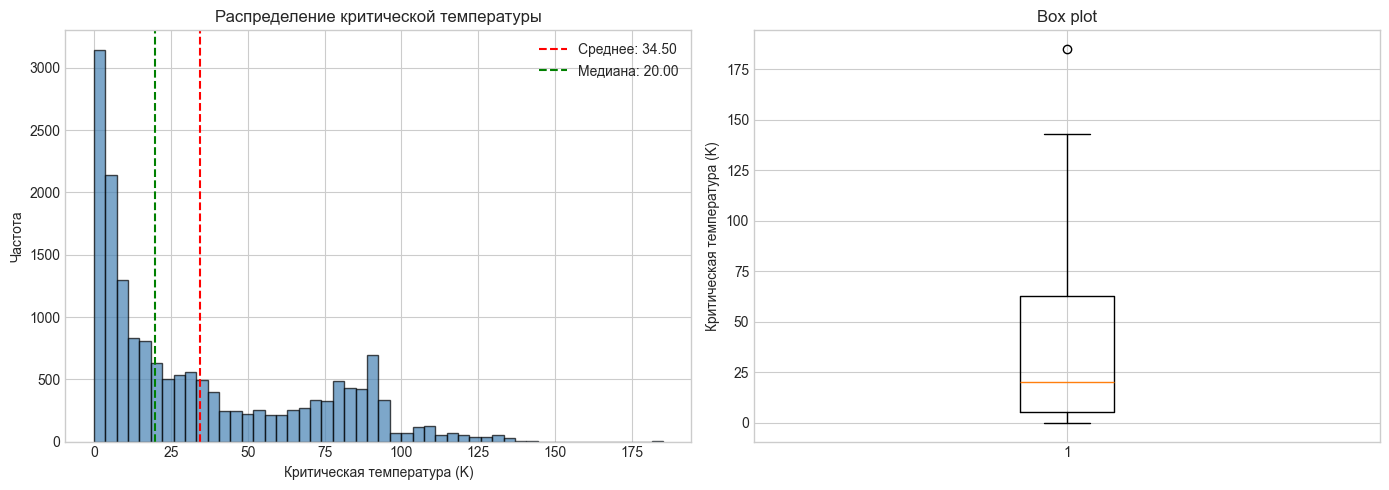

Минимум: 0.00 K
Максимум: 185.00 K
Среднее: 34.50 K
Стандартное отклонение: 34.33 K


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['critical_temp'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Критическая температура (K)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение критической температуры')
axes[0].axvline(train['critical_temp'].mean(), color='red', linestyle='--', label=f'Среднее: {train["critical_temp"].mean():.2f}')
axes[0].axvline(train['critical_temp'].median(), color='green', linestyle='--', label=f'Медиана: {train["critical_temp"].median():.2f}')
axes[0].legend()

axes[1].boxplot(train['critical_temp'], vert=True)
axes[1].set_ylabel('Критическая температура (K)')
axes[1].set_title('Box plot')

plt.tight_layout()
plt.show()

print(f"Минимум: {train['critical_temp'].min():.2f} K")
print(f"Максимум: {train['critical_temp'].max():.2f} K")
print(f"Среднее: {train['critical_temp'].mean():.2f} K")
print(f"Стандартное отклонение: {train['critical_temp'].std():.2f} K")

Пропусков нет.

In [105]:
feature_names = train.columns.drop('critical_temp').tolist()
print(f"Количество признаков: {len(feature_names)}")

properties = ['atomic_mass', 'fie', 'atomic_radius', 'Density', 'ElectronAffinity', 
              'FusionHeat', 'ThermalConductivity', 'Valence']

print("\nФизико-химические свойства:")
for prop in properties:
    prop_features = [f for f in feature_names if prop.lower() in f.lower()]
    print(f"  {prop}: {len(prop_features)} признаков")

Количество признаков: 81

Физико-химические свойства:
  atomic_mass: 10 признаков
  fie: 10 признаков
  atomic_radius: 10 признаков
  Density: 10 признаков
  ElectronAffinity: 10 признаков
  FusionHeat: 10 признаков
  ThermalConductivity: 10 признаков
  Valence: 10 признаков


In [106]:
correlations = train.corr()['critical_temp'].drop('critical_temp').sort_values(ascending=False)

print("Топ-15 положительных корреляций:")
print(correlations.head(15))
print("\nТоп-15 отрицательных корреляций:")
print(correlations.tail(15))

Топ-15 положительных корреляций:
wtd_std_ThermalConductivity    0.720447
range_ThermalConductivity      0.686461
range_atomic_radius            0.655900
std_ThermalConductivity        0.652652
wtd_entropy_atomic_mass        0.626545
range_fie                      0.604288
wtd_entropy_atomic_radius      0.603332
number_of_elements             0.601792
wtd_std_atomic_radius          0.600576
entropy_Valence                0.599583
wtd_entropy_Valence            0.589791
wtd_std_fie                    0.584195
entropy_fie                    0.568254
wtd_entropy_FusionHeat         0.562708
std_atomic_radius              0.562629
Name: critical_temp, dtype: float64

Топ-15 отрицательных корреляций:
gmean_ElectronAffinity      -0.379771
mean_FusionHeat             -0.387100
gmean_ThermalConductivity   -0.390227
wtd_mean_FusionHeat         -0.396486
wtd_gmean_atomic_radius     -0.406232
wtd_mean_Density            -0.432435
gmean_FusionHeat            -0.433056
wtd_gmean_FusionHeat        -0.

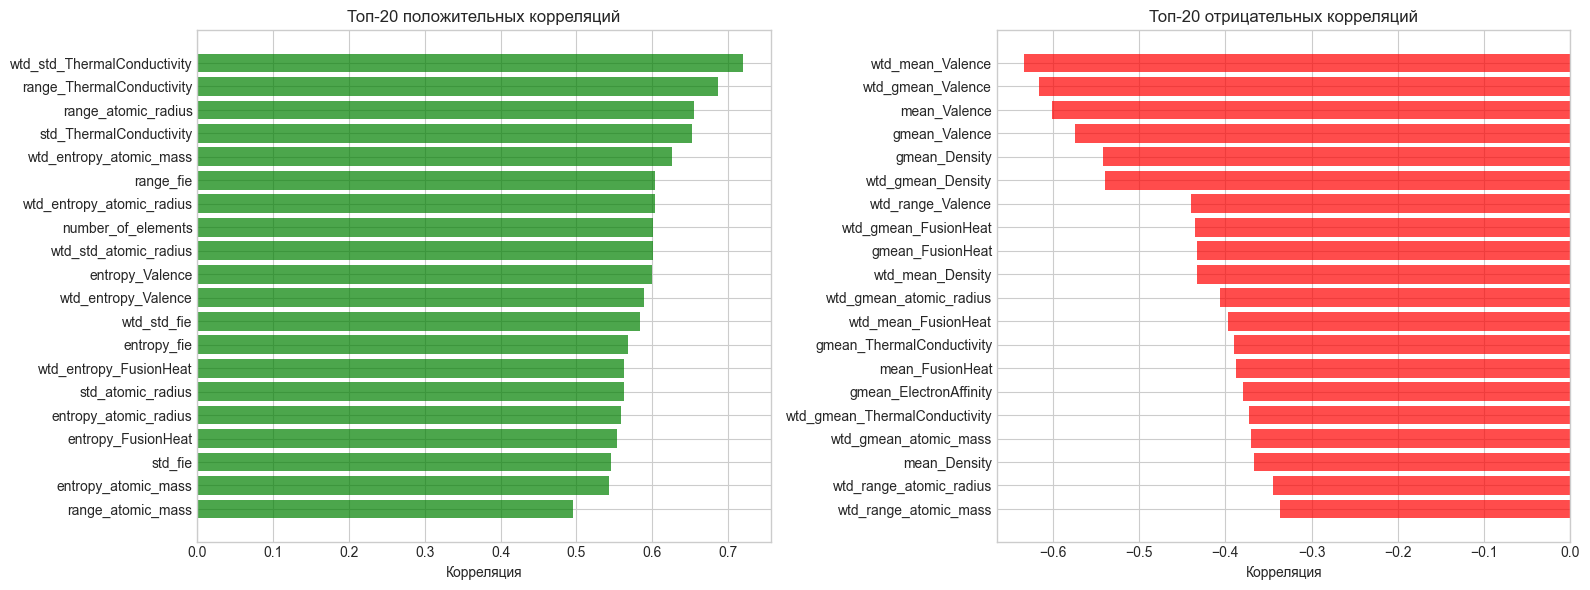

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_positive = correlations.head(20)
axes[0].barh(range(len(top_positive)), top_positive.values, color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive.index)
axes[0].set_xlabel('Корреляция')
axes[0].set_title('Топ-20 положительных корреляций')
axes[0].invert_yaxis()

top_negative = correlations.tail(20)
axes[1].barh(range(len(top_negative)), top_negative.values, color='red', alpha=0.7)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative.index)
axes[1].set_xlabel('Корреляция')
axes[1].set_title('Топ-20 отрицательных корреляций')

plt.tight_layout()
plt.show()

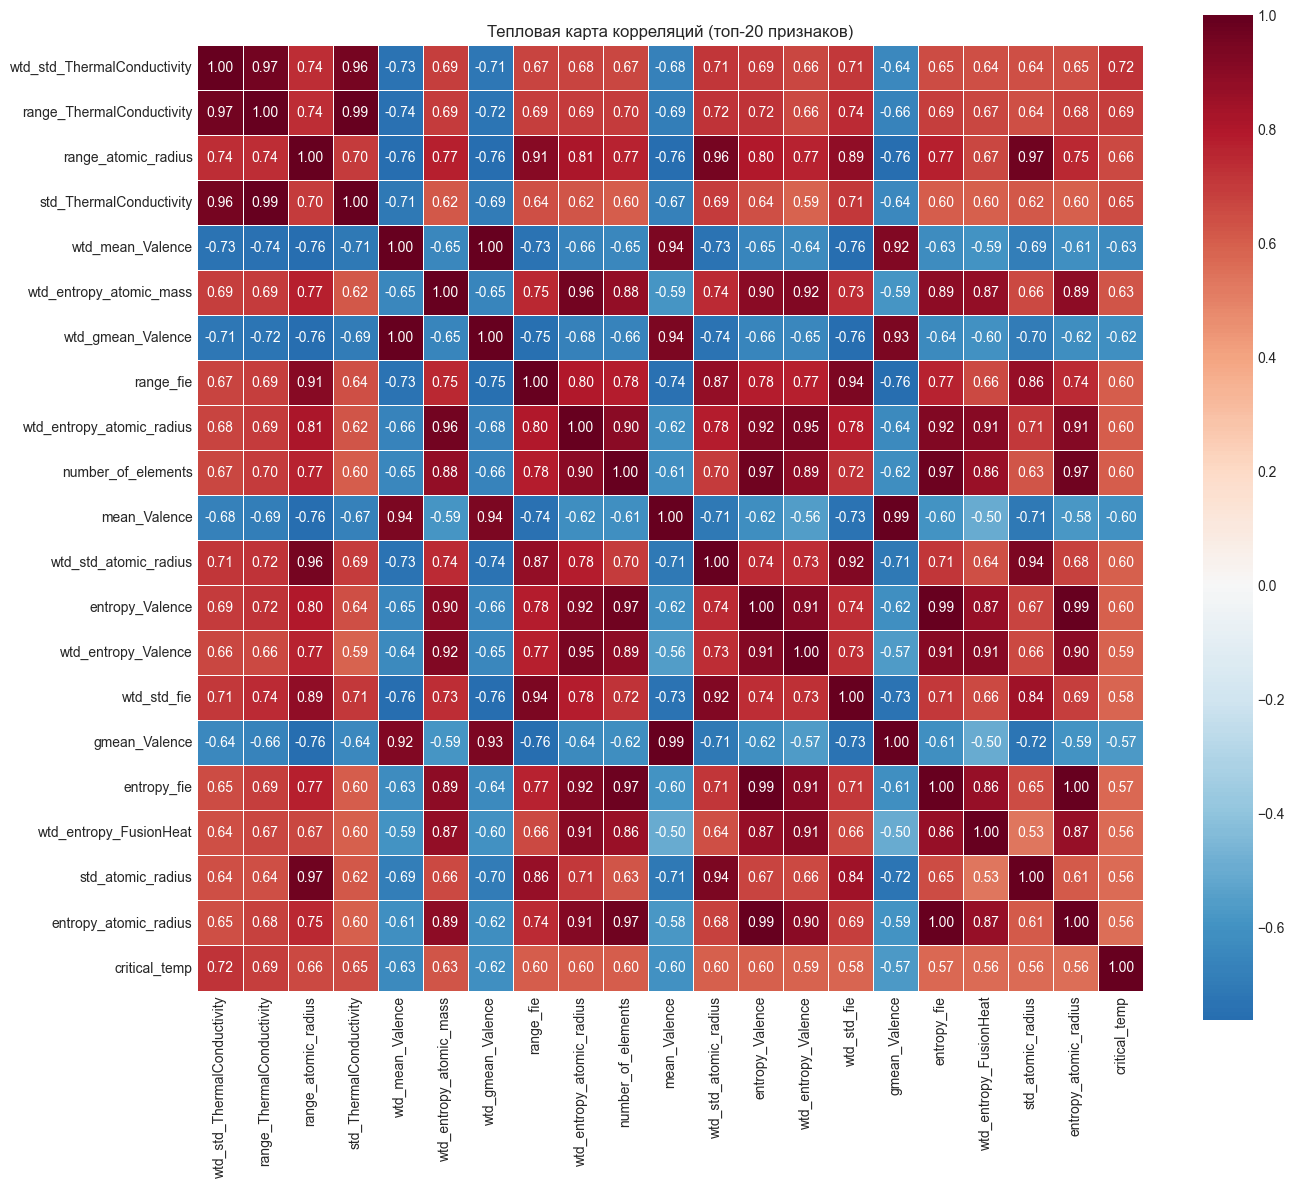

In [108]:
top_features = correlations.abs().sort_values(ascending=False).head(20).index.tolist()
top_features.append('critical_temp')

plt.figure(figsize=(14, 12))
sns.heatmap(train[top_features].corr(), annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций (топ-20 признаков)')
plt.tight_layout()
plt.show()

## Предобработка данных

In [109]:
X = train.drop('critical_temp', axis=1)
y = train['critical_temp']
X_test_final = test.copy()

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Размер X_test_final: {X_test_final.shape}")

Размер X: (17010, 81)
Размер y: (17010,)
Размер X_test_final: (4253, 81)


In [110]:
constant_features = [col for col in X.columns if X[col].std() == 0]
print(f"Константные признаки: {constant_features}")

if constant_features:
    X = X.drop(columns=constant_features)
    X_test_final = X_test_final.drop(columns=constant_features)
    print(f"Удалено {len(constant_features)} константных признаков")

Константные признаки: []


In [111]:
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"Найдено {len(high_corr_pairs)} пар признаков с корреляцией > 0.95")
if len(high_corr_pairs) > 0:
    print("Примеры:")
    for feat1, feat2, corr in high_corr_pairs[:5]:
        print(f"  {feat1} - {feat2}: {corr:.3f}")

Найдено 30 пар признаков с корреляцией > 0.95
Примеры:
  number_of_elements - entropy_fie: 0.973
  number_of_elements - entropy_atomic_radius: 0.972
  number_of_elements - entropy_Valence: 0.968
  wtd_mean_atomic_mass - wtd_gmean_atomic_mass: 0.965
  entropy_atomic_mass - entropy_fie: 0.965


Мультиколлинеарность присутствует.

In [112]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")

X_train: (13608, 81)
X_val: (3402, 81)


In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)

## Feature Engineering

In [114]:
def create_features(df):
    df_new = df.copy()
    
    if 'mean_atomic_mass' in df.columns and 'mean_Density' in df.columns:
        df_new['mass_density_ratio'] = df['mean_atomic_mass'] / (df['mean_Density'] + 1e-10)
    
    if 'wtd_mean_atomic_mass' in df.columns and 'mean_atomic_mass' in df.columns:
        df_new['wtd_mean_ratio_mass'] = df['wtd_mean_atomic_mass'] / (df['mean_atomic_mass'] + 1e-10)
    
    if 'wtd_mean_fie' in df.columns and 'mean_fie' in df.columns:
        df_new['wtd_mean_ratio_fie'] = df['wtd_mean_fie'] / (df['mean_fie'] + 1e-10)
    
    if 'mean_ElectronAffinity' in df.columns and 'mean_fie' in df.columns:
        df_new['electron_properties'] = df['mean_ElectronAffinity'] * df['mean_fie'] / 1000
    
    entropy_cols = [col for col in df.columns if 'entropy' in col.lower()]
    if entropy_cols:
        df_new['total_entropy'] = df[entropy_cols].sum(axis=1)
    
    std_cols = [col for col in df.columns if col.startswith('std_')]
    if std_cols:
        df_new['total_std'] = df[std_cols].sum(axis=1)
    
    return df_new

X_train_fe = create_features(X_train)
X_val_fe = create_features(X_val)
X_test_fe = create_features(X_test_final)

print(f"Было признаков: {X_train.shape[1]}")
print(f"Стало признаков: {X_train_fe.shape[1]}")

Было признаков: 81
Стало признаков: 87


In [115]:
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_val_fe_scaled = scaler_fe.transform(X_val_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

X_train_fe_scaled = pd.DataFrame(X_train_fe_scaled, columns=X_train_fe.columns, index=X_train_fe.index)
X_val_fe_scaled = pd.DataFrame(X_val_fe_scaled, columns=X_val_fe.columns, index=X_val_fe.index)
X_test_fe_scaled = pd.DataFrame(X_test_fe_scaled, columns=X_test_fe.columns)

## Отбор признаков и анализ важности

In [116]:
selector_f = SelectKBest(score_func=f_regression, k=40)
selector_f.fit(X_train_fe_scaled, y_train)

f_scores = pd.DataFrame({
    'feature': X_train_fe.columns,
    'score': selector_f.scores_
}).sort_values('score', ascending=False)

print("Топ-20 по F-score:")
print(f_scores.head(20))

Топ-20 по F-score:
                        feature         score
70  wtd_std_ThermalConductivity  14829.271383
67    range_ThermalConductivity  12321.572666
69      std_ThermalConductivity  10282.977369
27          range_atomic_radius  10201.063453
72             wtd_mean_Valence   9061.365398
6       wtd_entropy_atomic_mass   8742.977250
74            wtd_gmean_Valence   8311.591924
17                    range_fie   7760.437416
26    wtd_entropy_atomic_radius   7747.484181
0            number_of_elements   7674.376767
30        wtd_std_atomic_radius   7672.249768
71                 mean_Valence   7622.082672
75              entropy_Valence   7541.848109
76          wtd_entropy_Valence   7141.535401
20                  wtd_std_fie   7080.813227
73                gmean_Valence   6630.932071
15                  entropy_fie   6412.719853
56       wtd_entropy_FusionHeat   6284.556444
29            std_atomic_radius   6241.857449
25        entropy_atomic_radius   6119.110159


In [117]:
mi_scores = mutual_info_regression(X_train_fe_scaled, y_train, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'feature': X_train_fe.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("Топ-20 по Mutual Information:")
print(mi_df.head(20))

Топ-20 по Mutual Information:
                     feature  mi_score
19                   std_fie  0.867135
17                 range_fie  0.866071
33             gmean_Density  0.864754
69   std_ThermalConductivity  0.863883
25     entropy_atomic_radius  0.855662
5        entropy_atomic_mass  0.844682
47    range_ElectronAffinity  0.836189
35           entropy_Density  0.831967
72          wtd_mean_Valence  0.821587
74         wtd_gmean_Valence  0.819522
55        entropy_FusionHeat  0.818922
37             range_Density  0.817538
45  entropy_ElectronAffinity  0.815131
49      std_ElectronAffinity  0.805593
75           entropy_Valence  0.796565
61  mean_ThermalConductivity  0.794245
53          gmean_FusionHeat  0.793979
27       range_atomic_radius  0.789545
34         wtd_gmean_Density  0.789144
29         std_atomic_radius  0.785602


In [118]:
rf_for_importance = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_for_importance.fit(X_train_fe_scaled, y_train)

rf_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': rf_for_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-20 по важности Random Forest:")
print(rf_importance.head(20))

Топ-20 по важности Random Forest:
                            feature  importance
67        range_ThermalConductivity    0.540510
64    wtd_gmean_ThermalConductivity    0.122588
74                wtd_gmean_Valence    0.028141
66  wtd_entropy_ThermalConductivity    0.026958
9                   std_atomic_mass    0.016904
72                 wtd_mean_Valence    0.011051
8             wtd_range_atomic_mass    0.010149
31                     mean_Density    0.009516
78                wtd_range_Valence    0.009129
27              range_atomic_radius    0.008454
43           gmean_ElectronAffinity    0.008344
62     wtd_mean_ThermalConductivity    0.007427
80                  wtd_std_Valence    0.007376
29                std_atomic_radius    0.007142
86                        total_std    0.007108
50         wtd_std_ElectronAffinity    0.006632
35                  entropy_Density    0.006496
36              wtd_entropy_Density    0.006031
10              wtd_std_atomic_mass    0.005866
70    

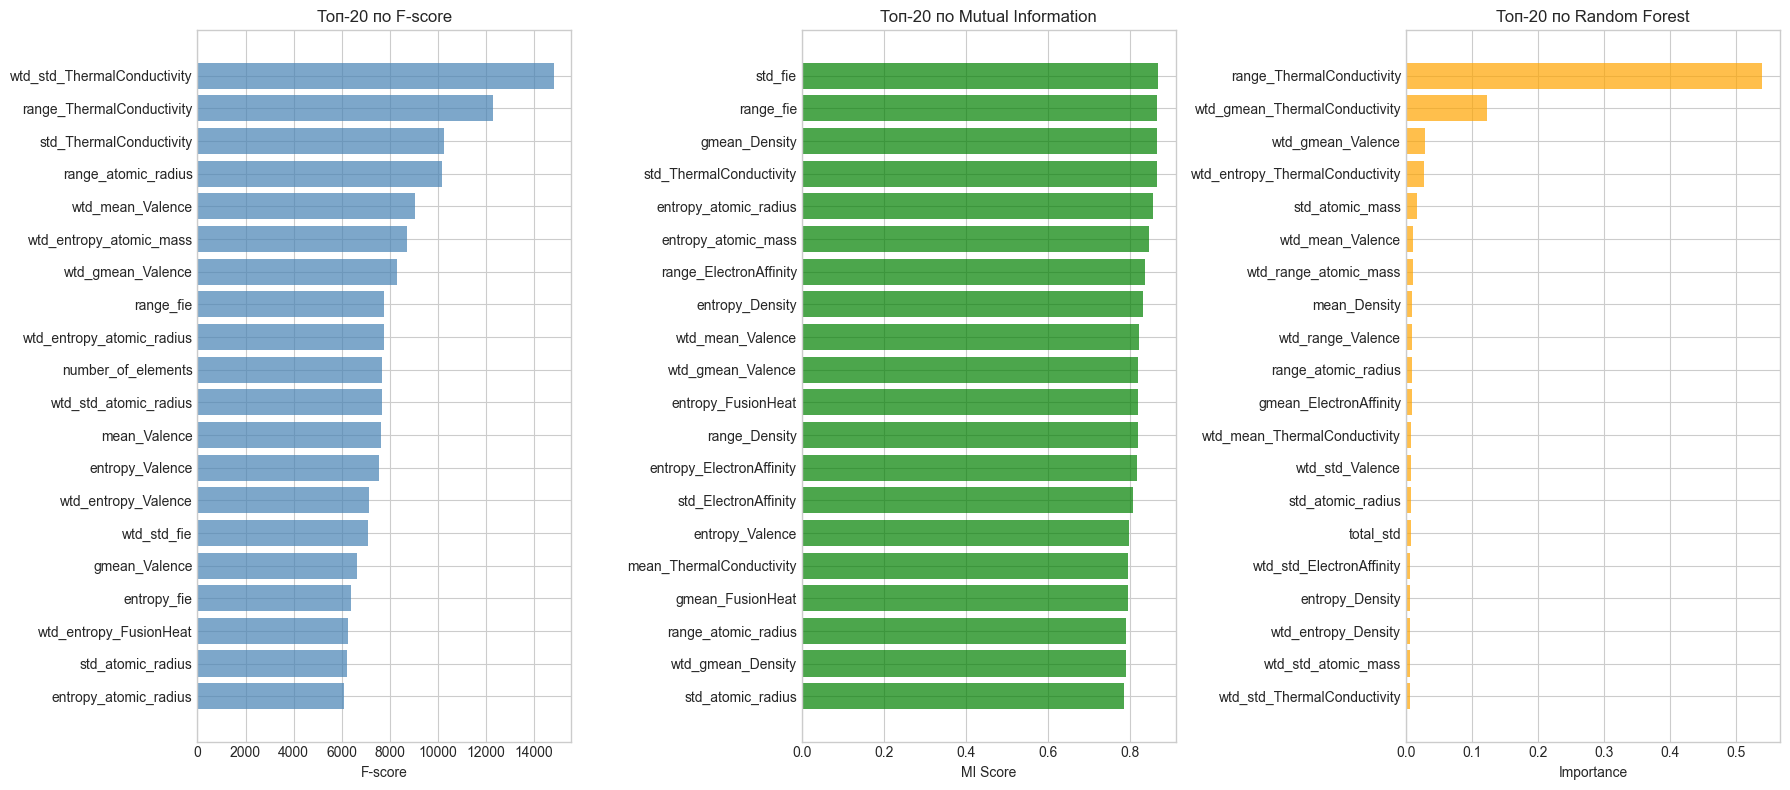

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

top_f = f_scores.head(20)
axes[0].barh(range(len(top_f)), top_f['score'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_f)))
axes[0].set_yticklabels(top_f['feature'].values)
axes[0].set_xlabel('F-score')
axes[0].set_title('Топ-20 по F-score')
axes[0].invert_yaxis()

top_mi = mi_df.head(20)
axes[1].barh(range(len(top_mi)), top_mi['mi_score'].values, color='green', alpha=0.7)
axes[1].set_yticks(range(len(top_mi)))
axes[1].set_yticklabels(top_mi['feature'].values)
axes[1].set_xlabel('MI Score')
axes[1].set_title('Топ-20 по Mutual Information')
axes[1].invert_yaxis()

top_rf = rf_importance.head(20)
axes[2].barh(range(len(top_rf)), top_rf['importance'].values, color='orange', alpha=0.7)
axes[2].set_yticks(range(len(top_rf)))
axes[2].set_yticklabels(top_rf['feature'].values)
axes[2].set_xlabel('Importance')
axes[2].set_title('Топ-20 по Random Forest')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [120]:
top_20_f = set(f_scores.head(30)['feature'].values)
top_20_mi = set(mi_df.head(30)['feature'].values)
top_20_rf = set(rf_importance.head(30)['feature'].values)

common_features = top_20_f & top_20_mi & top_20_rf
print(f"Признаки в топ-30 по всем трём методам: {len(common_features)}")
print(common_features)

Признаки в топ-30 по всем трём методам: 7
{'wtd_mean_Valence', 'range_atomic_radius', 'wtd_gmean_Valence', 'std_atomic_radius', 'entropy_Density', 'wtd_std_ThermalConductivity', 'wtd_std_fie'}


Важные признаки видны на графиках выше.

## Обучение моделей

In [121]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    
    y_train_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_v)
    
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    train_mae = mean_absolute_error(y_tr, y_train_pred)
    train_r2 = r2_score(y_tr, y_train_pred)
    
    val_rmse = np.sqrt(mean_squared_error(y_v, y_val_pred))
    val_mae = mean_absolute_error(y_v, y_val_pred)
    val_r2 = r2_score(y_v, y_val_pred)
    
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()
    
    results = {
        'Model': name,
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Val RMSE': val_rmse,
        'Val MAE': val_mae,
        'Val R2': val_r2,
        'CV RMSE': cv_rmse,
        'CV Std': cv_std
    }
    
    return results, model

In [122]:
results_list = []
trained_models = {}

In [123]:
lr = LinearRegression()
results, trained_lr = evaluate_model(lr, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, 'Linear Regression')
results_list.append(results)
trained_models['Linear Regression'] = trained_lr

print("Linear Regression:")
for key, value in results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

Linear Regression:
  Train RMSE: 17.5052
  Train MAE: 13.2369
  Train R2: 0.7378
  Val RMSE: 108.9311
  Val MAE: 15.3557
  Val R2: -8.7479
  CV RMSE: 17.6135
  CV Std: 0.3400


In [124]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
results, trained_ridge = evaluate_model(ridge, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, 'Ridge')
results_list.append(results)
trained_models['Ridge'] = trained_ridge

print("Ridge:")
for key, value in results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

Ridge:
  Train RMSE: 17.5161
  Train MAE: 13.2400
  Train R2: 0.7375
  Val RMSE: 116.0636
  Val MAE: 15.5026
  Val R2: -10.0663
  CV RMSE: 17.6223
  CV Std: 0.3353


In [125]:
lasso = Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=50000)
results, trained_lasso = evaluate_model(lasso, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, 'Lasso')
results_list.append(results)
trained_models['Lasso'] = trained_lasso

print("Lasso:")
for key, value in results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

Lasso:
  Train RMSE: 18.3863
  Train MAE: 14.0088
  Train R2: 0.7108
  Val RMSE: 18.7539
  Val MAE: 14.4668
  Val R2: 0.7111
  CV RMSE: 18.4411
  CV Std: 0.2826


In [126]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=50000)
results, trained_elastic = evaluate_model(elastic, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, 'ElasticNet')
results_list.append(results)
trained_models['ElasticNet'] = trained_elastic

print("ElasticNet:")
for key, value in results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

ElasticNet:
  Train RMSE: 18.8160
  Train MAE: 14.4659
  Train R2: 0.6971
  Val RMSE: 44.3674
  Val MAE: 15.6064
  Val R2: -0.6171
  CV RMSE: 18.8543
  CV Std: 0.2838


In [127]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
results, trained_rf = evaluate_model(rf, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, 'Random Forest')
results_list.append(results)
trained_models['Random Forest'] = trained_rf

print("Random Forest:")
for key, value in results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

Random Forest:
  Train RMSE: 5.7334
  Train MAE: 3.2741
  Train R2: 0.9719
  Val RMSE: 9.8303
  Val MAE: 5.7184
  Val R2: 0.9206
  CV RMSE: 10.0832
  CV Std: 0.4488


In [128]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE)
results, trained_gb = evaluate_model(gb, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, 'Gradient Boosting')
results_list.append(results)
trained_models['Gradient Boosting'] = trained_gb

print("Gradient Boosting:")
for key, value in results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

Gradient Boosting:
  Train RMSE: 8.7457
  Train MAE: 5.8506
  Train R2: 0.9346
  Val RMSE: 10.7294
  Val MAE: 6.9538
  Val R2: 0.9054
  CV RMSE: 10.9782
  CV Std: 0.4367


In [129]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('Val RMSE')
print("Сравнение моделей:")
print(results_df.to_string(index=False))

Сравнение моделей:
            Model  Train RMSE  Train MAE  Train R2   Val RMSE   Val MAE     Val R2   CV RMSE   CV Std
    Random Forest    5.733387   3.274136  0.971875   9.830281  5.718366   0.920615 10.083204 0.448797
Gradient Boosting    8.745654   5.850618  0.934559  10.729446  6.953845   0.905428 10.978211 0.436694
            Lasso   18.386296  14.008849  0.710762  18.753915 14.466775   0.711070 18.441107 0.282643
       ElasticNet   18.815964  14.465891  0.697086  44.367403 15.606435  -0.617101 18.854258 0.283804
Linear Regression   17.505249  13.236859  0.737818 108.931075 15.355718  -8.747940 17.613453 0.339967
            Ridge   17.516067  13.240016  0.737494 116.063615 15.502597 -10.066275 17.622336 0.335256


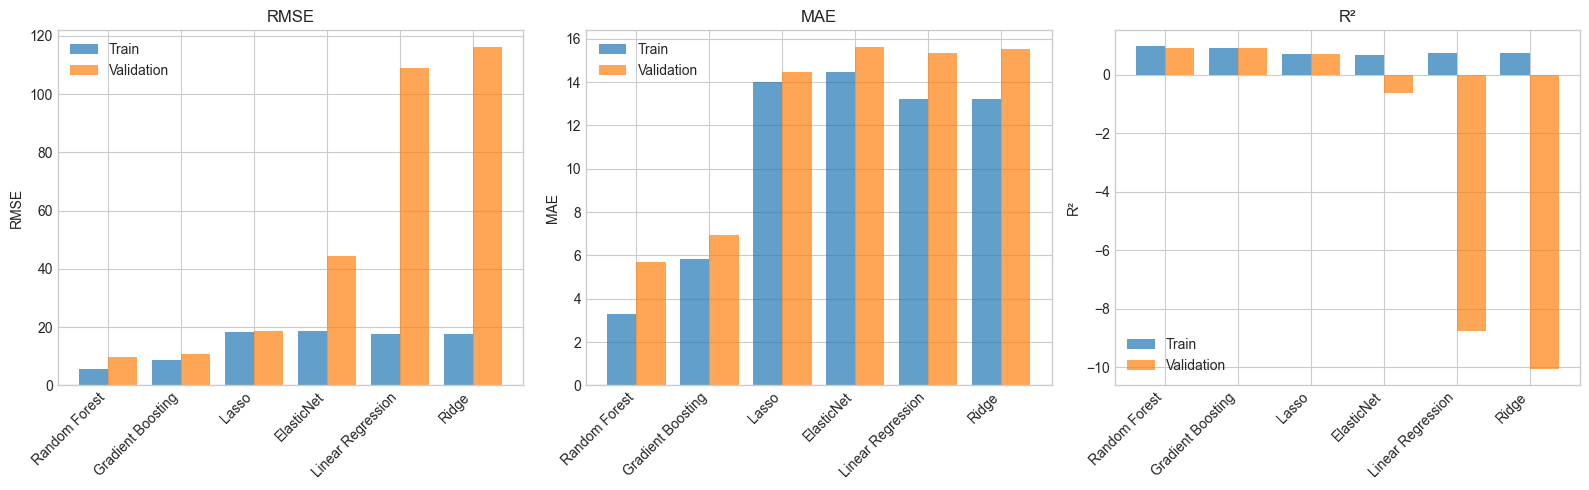

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_names = results_df['Model'].values
x_pos = np.arange(len(models_names))

axes[0].bar(x_pos - 0.2, results_df['Train RMSE'], width=0.4, label='Train', alpha=0.7)
axes[0].bar(x_pos + 0.2, results_df['Val RMSE'], width=0.4, label='Validation', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE')
axes[0].legend()

axes[1].bar(x_pos - 0.2, results_df['Train MAE'], width=0.4, label='Train', alpha=0.7)
axes[1].bar(x_pos + 0.2, results_df['Val MAE'], width=0.4, label='Validation', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_names, rotation=45, ha='right')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE')
axes[1].legend()

axes[2].bar(x_pos - 0.2, results_df['Train R2'], width=0.4, label='Train', alpha=0.7)
axes[2].bar(x_pos + 0.2, results_df['Val R2'], width=0.4, label='Validation', alpha=0.7)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models_names, rotation=45, ha='right')
axes[2].set_ylabel('R²')
axes[2].set_title('R²')
axes[2].legend()

plt.tight_layout()
plt.show()

Random Forest дал лучший результат.

## Подбор гиперпараметров

In [131]:
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_fe_scaled, y_train)

print(f"Ridge лучший alpha: {ridge_grid.best_params_['alpha']}")
print(f"CV RMSE: {-ridge_grid.best_score_:.4f}")

Ridge лучший alpha: 0.1
CV RMSE: 17.6131


In [132]:
lasso_params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]}

lasso_grid = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=50000),
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lasso_grid.fit(X_train_fe_scaled, y_train)

print(f"Lasso лучший alpha: {lasso_grid.best_params_['alpha']}")
print(f"CV RMSE: {-lasso_grid.best_score_:.4f}")

Lasso лучший alpha: 0.001
CV RMSE: 17.6149


In [ ]:
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    ElasticNet(random_state=RANDOM_STATE, max_iter=50000),
    elastic_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
elastic_grid.fit(X_train_fe_scaled, y_train)

print(f"ElasticNet лучшие параметры: {elastic_grid.best_params_}")
print(f"CV RMSE: {-elastic_grid.best_score_:.4f}")

In [ ]:
rf_params = {
    'n_estimators': [100],
    'max_depth': [15, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train_fe_scaled, y_train)

print("Random Forest лучшие параметры:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"CV RMSE: {-rf_grid.best_score_:.4f}")

Random Forest лучшие параметры:
  max_depth: 20
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100
CV RMSE: 10.2007


In [ ]:
gb_params = {
    'n_estimators': [100],
    'max_depth': [5, 7],
    'learning_rate': [0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gb_grid.fit(X_train_fe_scaled, y_train)

print("Gradient Boosting лучшие параметры:")
for param, value in gb_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"CV RMSE: {-gb_grid.best_score_:.4f}")

Gradient Boosting лучшие параметры:
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 100
CV RMSE: 10.2913


In [ ]:
tuned_results = []

for name, model in [('Ridge (tuned)', ridge_grid.best_estimator_),
                     ('Lasso (tuned)', lasso_grid.best_estimator_),
                     ('ElasticNet (tuned)', elastic_grid.best_estimator_),
                     ('Random Forest (tuned)', rf_grid.best_estimator_),
                     ('Gradient Boosting (tuned)', gb_grid.best_estimator_)]:
    results, _ = evaluate_model(model, X_train_fe_scaled, y_train, X_val_fe_scaled, y_val, name)
    tuned_results.append(results)

tuned_df = pd.DataFrame(tuned_results).sort_values('Val RMSE')
print("Результаты после подбора гиперпараметров:")
print(tuned_df.to_string(index=False))

Результаты после подбора гиперпараметров:
                    Model  Train RMSE  Train MAE  Train R2   Val RMSE   Val MAE    Val R2   CV RMSE   CV Std
    Random Forest (tuned)    5.132182   2.714423  0.977464   9.757777  5.565690  0.921781 10.014406 0.443950
Gradient Boosting (tuned)    6.362085   4.118793  0.965369  10.032142  6.057145  0.917321 10.221872 0.449469
            Ridge (tuned)   17.505551  13.235860  0.737809 110.738904 15.388986 -9.074180 17.613071 0.339254
            Lasso (tuned)   17.509499  13.229149  0.737690 111.239505 15.403867 -9.165467 17.614946 0.337807
       ElasticNet (tuned)   17.527438  13.243881  0.737153 113.098109 15.467501 -9.507997 17.628512 0.334076


## Выбор лучшей модели

In [ ]:
best_model_name = tuned_df.iloc[0]['Model']
best_val_rmse = tuned_df.iloc[0]['Val RMSE']

model_mapping = {
    'Ridge (tuned)': ridge_grid.best_estimator_,
    'Lasso (tuned)': lasso_grid.best_estimator_,
    'ElasticNet (tuned)': elastic_grid.best_estimator_,
    'Random Forest (tuned)': rf_grid.best_estimator_,
    'Gradient Boosting (tuned)': gb_grid.best_estimator_
}

best_model = model_mapping[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"Val RMSE: {best_val_rmse:.4f}")
print(f"\nПараметры:")
print(best_model.get_params())

Лучшая модель: Random Forest (tuned)
Val RMSE: 9.7578

Параметры:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 100, 'verbose': 0, 'warm_start': False}


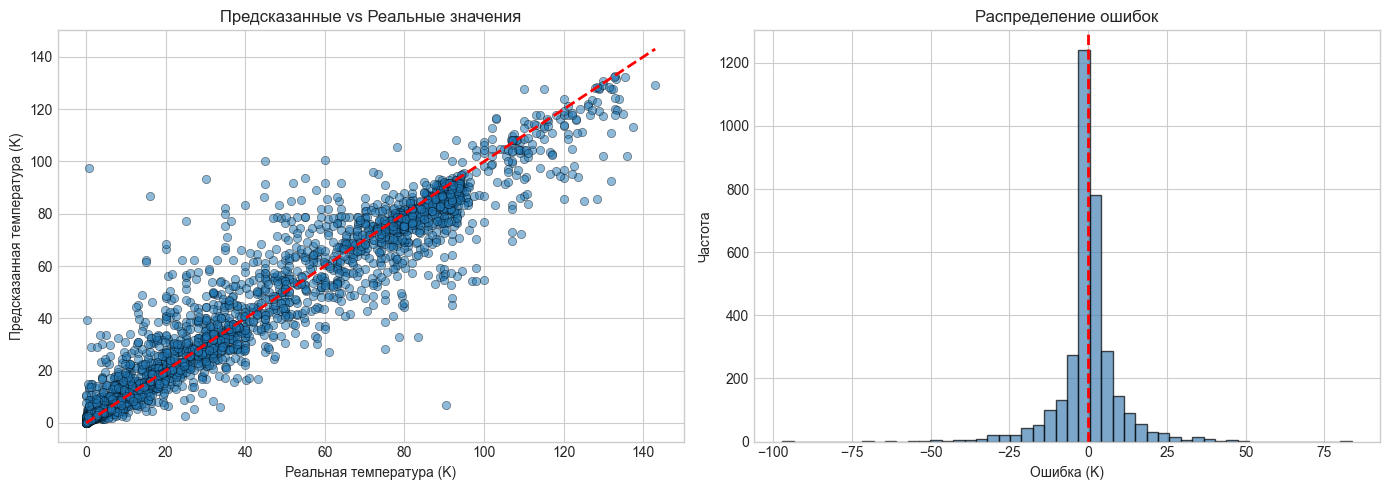

Средняя ошибка: 0.19 K
Стд ошибки: 9.76 K


In [ ]:
y_val_pred = best_model.predict(X_val_fe_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val, y_val_pred, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Реальная температура (K)')
axes[0].set_ylabel('Предсказанная температура (K)')
axes[0].set_title('Предсказанные vs Реальные значения')

errors = y_val - y_val_pred
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Ошибка (K)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок')

plt.tight_layout()
plt.show()

print(f"Средняя ошибка: {errors.mean():.2f} K")
print(f"Стд ошибки: {errors.std():.2f} K")

In [ ]:
X_full = pd.concat([X_train_fe, X_val_fe], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full)
X_test_final_scaled = scaler_final.transform(X_test_fe)

if 'Random Forest' in best_model_name:
    final_model = RandomForestRegressor(**rf_grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
elif 'Gradient Boosting' in best_model_name:
    final_model = GradientBoostingRegressor(**gb_grid.best_params_, random_state=RANDOM_STATE)
elif 'Ridge' in best_model_name:
    final_model = Ridge(**ridge_grid.best_params_, random_state=RANDOM_STATE)
elif 'Lasso' in best_model_name:
    final_model = Lasso(**lasso_grid.best_params_, random_state=RANDOM_STATE, max_iter=50000)
elif 'ElasticNet' in best_model_name:
    final_model = ElasticNet(**elastic_grid.best_params_, random_state=RANDOM_STATE, max_iter=50000)

final_model.fit(X_full_scaled, y_full)
print("Финальная модель обучена на всех данных")

Финальная модель обучена на всех данных


Random Forest выбран по минимальному RMSE.

## Предсказание и формирование submission

In [ ]:
test_predictions = final_model.predict(X_test_final_scaled)

print(f"Количество предсказаний: {len(test_predictions)}")
print(f"Минимум: {test_predictions.min():.2f} K")
print(f"Максимум: {test_predictions.max():.2f} K")
print(f"Среднее: {test_predictions.mean():.2f} K")

Количество предсказаний: 4253
Минимум: 0.03 K
Максимум: 133.85 K
Среднее: 34.22 K


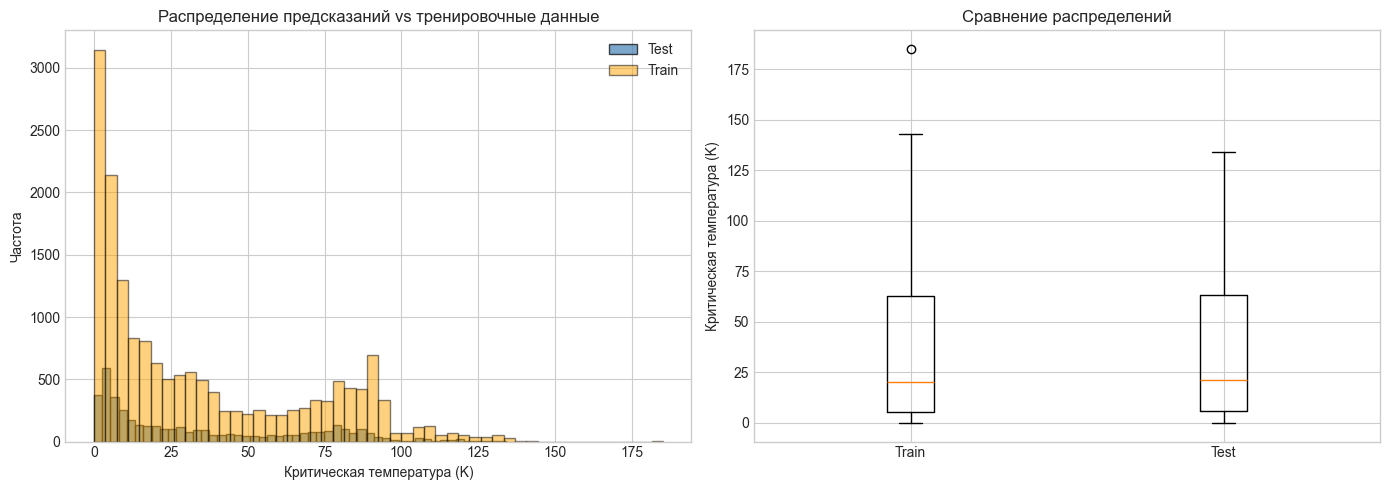

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_predictions, bins=50, edgecolor='black', alpha=0.7, color='steelblue', label='Test')
axes[0].hist(y_full, bins=50, edgecolor='black', alpha=0.5, color='orange', label='Train')
axes[0].set_xlabel('Критическая температура (K)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение предсказаний vs тренировочные данные')
axes[0].legend()

axes[1].boxplot([y_full, test_predictions], labels=['Train', 'Test'])
axes[1].set_ylabel('Критическая температура (K)')
axes[1].set_title('Сравнение распределений')

plt.tight_layout()
plt.show()

In [ ]:
submission = pd.DataFrame({
    'index': range(len(test_predictions)),
    'critical_temp': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Файл submission.csv создан")
print(submission.head(10))

Файл submission.csv создан
   index  critical_temp
0      0      32.293567
1      1      25.539979
2      2      89.400574
3      3      78.300177
4      4      87.391190
5      5      90.859464
6      6      87.357262
7      7      74.918667
8      8      88.572333
9      9      65.400596


In [ ]:
print(f"Проверка формата:")
print(f"  Строк: {len(submission)}")
print(f"  Колонки: {submission.columns.tolist()}")

Проверка формата:
  Строк: 4253
  Колонки: ['index', 'critical_temp']


## Выводы

Лучший результат показал Random Forest (RMSE ≈ 9.76 K, R² ≈ 0.92). Линейные модели не подошли. Kaggle RMSE = 93.40.

## Скриншот с Kaggle

![Kaggle Score](image.png)